# Klasifikasi Naive Bayes pada Dataset Akademik Mahasiswa


**Nama**: I Gusti Nyoman Pramajaya

**NIM**: 2308561094

**Mata Kuliah**: Data Digital

**Dataset**: Student Academic Performance (4.424 data, 37 variabel)



## Deskripsi Tugas

Notebook ini berisi implementasi algoritma **Naive Bayes** untuk mengklasifikasikan status akademik mahasiswa menjadi tiga kelas: **Graduate** (Lulus), **Dropout** (Keluar), dan **Enrolled** (Masih Aktif). Proses meliputi eksplorasi data, pra-pemrosesan, pemodelan, evaluasi, serta upaya peningkatan akurasi.

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, PowerTransformer, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

# Label kelas
KELAS = ['Dropout', 'Enrolled', 'Graduate']

print('Library berhasil diimport.')

Library berhasil diimport.


---
## 2. Memuat dan Memahami Data

In [2]:
# Memuat dataset
df_data = pd.read_csv('data.csv', sep=';')

print(f'Jumlah baris  : {df_data.shape[0]:,}')
print(f'Jumlah kolom  : {df_data.shape[1]}')
print(f'Kolom target  : Status')
print()

# Tampilkan 5 baris pertama
df_data.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37
Kolom target  : Status



,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Informasi tipe data dan missing value
print('Informasi dataset:')
df_data.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

In [4]:
# Distribusi kelas target
distribusi_kelas = df_data['Status'].value_counts()
print('Distribusi Kelas Target:')
for kelas, jumlah in distribusi_kelas.items():
    pct = jumlah / len(df_data) * 100
    print(f'  {kelas:<12}: {jumlah:,} data ({pct:.1f}%)')

Distribusi Kelas Target:
  Graduate    : 2,209 data (49.9%)
  Dropout     : 1,421 data (32.1%)
  Enrolled    : 794 data (17.9%)


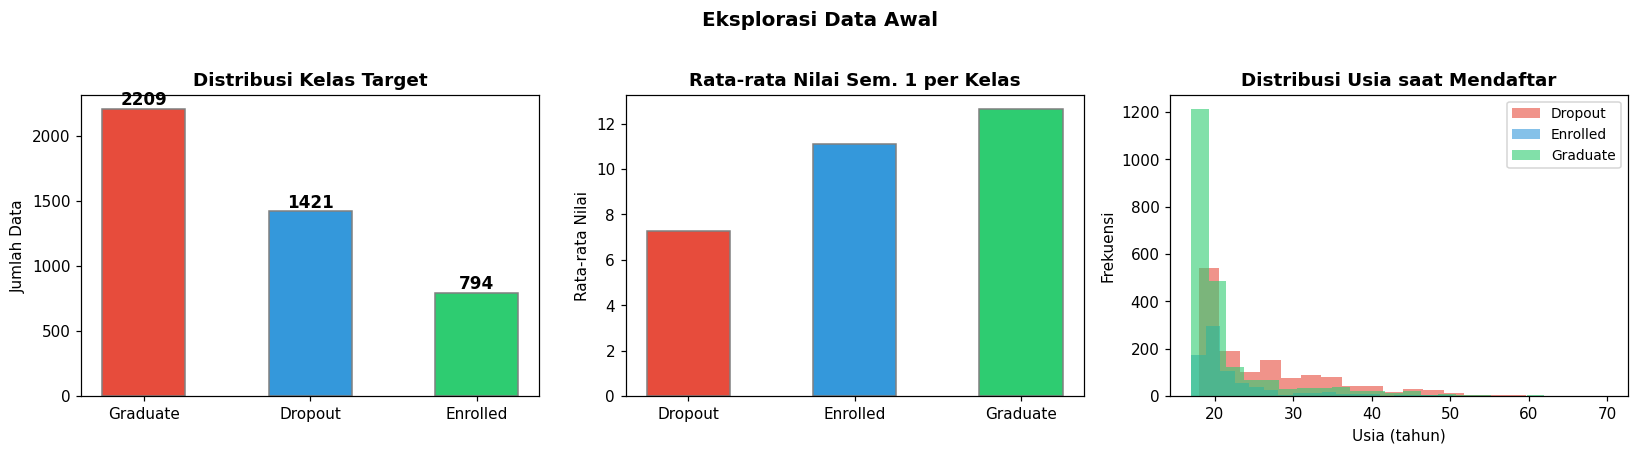

In [5]:
# Visualisasi distribusi kelas & fitur penting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribusi kelas
warna_kelas = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(distribusi_kelas.index, distribusi_kelas.values,
            color=warna_kelas, edgecolor='gray', width=0.5)
for i, (kls, jml) in enumerate(distribusi_kelas.items()):
    axes[0].text(i, jml + 30, f'{jml}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')

# 2. Rata-rata nilai semester per kelas
rata_nilai = df_data.groupby('Status')['Curricular_units_1st_sem_grade'].mean()
axes[1].bar(rata_nilai.index, rata_nilai.values,
            color=warna_kelas, edgecolor='gray', width=0.5)
axes[1].set_title('Rata-rata Nilai Sem. 1 per Kelas', fontweight='bold')
axes[1].set_ylabel('Rata-rata Nilai')

# 3. Distribusi usia saat mendaftar
for kls, wrn in zip(['Dropout','Enrolled','Graduate'], warna_kelas):
    axes[2].hist(df_data[df_data['Status']==kls]['Age_at_enrollment'],
                 bins=20, alpha=0.6, color=wrn, label=kls, edgecolor='none')
axes[2].set_title('Distribusi Usia saat Mendaftar', fontweight='bold')
axes[2].set_xlabel('Usia (tahun)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=9)

plt.suptitle('Eksplorasi Data Awal', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Pra-pemrosesan Data (Preprocessing)

Tahap preprocessing mencakup: (1) pengecekan duplikat dan *missing value*, (2) penanganan *outlier*, (3) rekayasa fitur, (4) seleksi fitur, (5) encoding target, serta (6) pembagian dan normalisasi data.

### 3.1 Pengecekan Duplikat dan *Missing Value*

In [6]:
jumlah_duplikat   = df_data.duplicated().sum()
jumlah_hilang     = df_data.isnull().sum().sum()

print(f'Jumlah baris duplikat  : {jumlah_duplikat}')
print(f'Jumlah nilai hilang    : {jumlah_hilang}')
print()

if jumlah_duplikat > 0:
    df_data = df_data.drop_duplicates().reset_index(drop=True)
    print(f'→ Duplikat dihapus. Sisa data: {len(df_data):,}')
else:
    print('→ Tidak ditemukan duplikat maupun nilai hilang. Data sudah bersih.')

Jumlah baris duplikat  : 0
Jumlah nilai hilang    : 0

→ Tidak ditemukan duplikat maupun nilai hilang. Data sudah bersih.


### 3.2 Penanganan *Outlier* (IQR Winsorizing)

In [7]:
# Kolom numerik kontinu yang perlu dicek outlier
kolom_kontinu = [
    'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment',
    'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

df_bersih = df_data.copy()
total_sel_di_cap = 0

for kolom in kolom_kontinu:
    Q1  = df_bersih[kolom].quantile(0.25)
    Q3  = df_bersih[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    jumlah_outlier = ((df_bersih[kolom] < batas_bawah) | (df_bersih[kolom] > batas_atas)).sum()
    total_sel_di_cap += jumlah_outlier
    df_bersih[kolom] = df_bersih[kolom].clip(lower=batas_bawah, upper=batas_atas)

print(f'Metode penanganan outlier : IQR Winsorizing (Capping)')
print(f'Total nilai yang di-cap   : {total_sel_di_cap}')
print(f'Jumlah baris tetap        : {len(df_bersih):,} (tidak ada baris yang dihapus)')

Metode penanganan outlier : IQR Winsorizing (Capping)
Total nilai yang di-cap   : 5276
Jumlah baris tetap        : 4,424 (tidak ada baris yang dihapus)


### 3.3 Rekayasa Fitur (*Feature Engineering*)

In [8]:
# Membuat fitur turunan yang lebih informatif

# 1. Tingkat kelulusan semester 1 & 2
df_bersih['Tingkat_Lulus_Sem1'] = np.where(
    df_bersih['Curricular_units_1st_sem_enrolled'] > 0,
    df_bersih['Curricular_units_1st_sem_approved'] / df_bersih['Curricular_units_1st_sem_enrolled'],
    0
)
df_bersih['Tingkat_Lulus_Sem2'] = np.where(
    df_bersih['Curricular_units_2nd_sem_enrolled'] > 0,
    df_bersih['Curricular_units_2nd_sem_approved'] / df_bersih['Curricular_units_2nd_sem_enrolled'],
    0
)

# 2. Total mata kuliah lulus
df_bersih['Total_MK_Lulus'] = (
    df_bersih['Curricular_units_1st_sem_approved'] +
    df_bersih['Curricular_units_2nd_sem_approved']
)

# 3. Rata-rata nilai dua semester
df_bersih['Rata_Nilai'] = (
    df_bersih['Curricular_units_1st_sem_grade'] +
    df_bersih['Curricular_units_2nd_sem_grade']
) / 2

# 4. Performa terbobot (nilai × tingkat lulus)
df_bersih['Performa_Sem1'] = df_bersih['Tingkat_Lulus_Sem1'] * df_bersih['Curricular_units_1st_sem_grade']
df_bersih['Performa_Sem2'] = df_bersih['Tingkat_Lulus_Sem2'] * df_bersih['Curricular_units_2nd_sem_grade']

# 5. Stabilitas keuangan
df_bersih['Stabilitas_Keuangan'] = (
    df_bersih['Scholarship_holder'].astype(int) +
    df_bersih['Tuition_fees_up_to_date'].astype(int) -
    df_bersih['Debtor'].astype(int)
)

# 6. Kemajuan nilai antar semester
df_bersih['Kemajuan_Nilai'] = (
    df_bersih['Curricular_units_2nd_sem_grade'] -
    df_bersih['Curricular_units_1st_sem_grade']
)

fitur_baru = ['Tingkat_Lulus_Sem1','Tingkat_Lulus_Sem2','Total_MK_Lulus',
              'Rata_Nilai','Performa_Sem1','Performa_Sem2',
              'Stabilitas_Keuangan','Kemajuan_Nilai']

print(f'Fitur baru berhasil dibuat ({len(fitur_baru)} fitur):')
for f in fitur_baru:
    print(f'  • {f}')

Fitur baru berhasil dibuat (8 fitur):
  • Tingkat_Lulus_Sem1
  • Tingkat_Lulus_Sem2
  • Total_MK_Lulus
  • Rata_Nilai
  • Performa_Sem1
  • Performa_Sem2
  • Stabilitas_Keuangan
  • Kemajuan_Nilai


### 3.4 Seleksi Fitur (*Mutual Information*)

In [9]:
# Encoding target sementara untuk mutual information
le_temp = LabelEncoder()
y_temp  = le_temp.fit_transform(df_bersih['Status'])

# Hapus kolom yang tidak relevan
kolom_hapus = ['Status', 'Application_order', 'Course', 'Nacionality']
X_semua     = df_bersih.drop(columns=kolom_hapus)

# Hitung Mutual Information
skor_mi  = mutual_info_classif(X_semua, y_temp, random_state=42)
df_mi    = pd.DataFrame({'Fitur': X_semua.columns, 'Skor MI': skor_mi})
df_mi    = df_mi.sort_values('Skor MI', ascending=False).reset_index(drop=True)

# Pilih fitur dengan MI >= 0.02
AMBANG_MI      = 0.02
fitur_terpilih = df_mi[df_mi['Skor MI'] >= AMBANG_MI]['Fitur'].tolist()
fitur_dibuang  = df_mi[df_mi['Skor MI'] <  AMBANG_MI]['Fitur'].tolist()

print(f'Metode seleksi fitur : Mutual Information (ambang MI >= {AMBANG_MI})')
print(f'Jumlah fitur semula  : {X_semua.shape[1]}')
print(f'Fitur terpilih       : {len(fitur_terpilih)}')
print(f'Fitur dibuang        : {len(fitur_dibuang)}')
print()
print('10 Fitur Paling Informatif:')
print(df_mi.head(10).to_string(index=False))

Metode seleksi fitur : Mutual Information (ambang MI >= 0.02)
Jumlah fitur semula  : 41
Fitur terpilih       : 28
Fitur dibuang        : 13

10 Fitur Paling Informatif:
                            Fitur  Skor MI
                    Performa_Sem2 0.341295
               Tingkat_Lulus_Sem2 0.339260
Curricular_units_2nd_sem_approved 0.313995
                   Total_MK_Lulus 0.313639
                    Performa_Sem1 0.271987
               Tingkat_Lulus_Sem1 0.270785
   Curricular_units_2nd_sem_grade 0.246343
Curricular_units_1st_sem_approved 0.244371
                       Rata_Nilai 0.238023
   Curricular_units_1st_sem_grade 0.196203


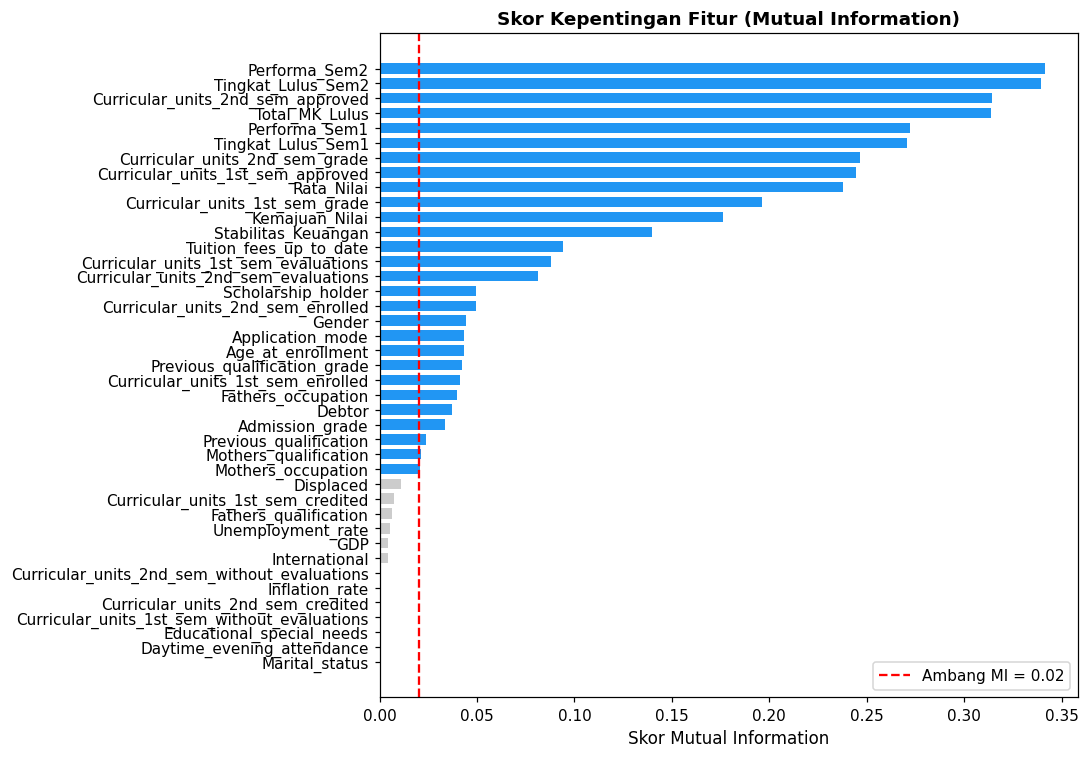

In [10]:
# Visualisasi skor fitur
fig, ax = plt.subplots(figsize=(10, 7))
warna_bar = ['#2196F3' if s >= AMBANG_MI else '#cccccc' for s in df_mi['Skor MI']]
ax.barh(df_mi['Fitur'][::-1], df_mi['Skor MI'][::-1], color=warna_bar[::-1], height=0.7)
ax.axvline(AMBANG_MI, color='red', linestyle='--', linewidth=1.5, label=f'Ambang MI = {AMBANG_MI}')
ax.set_xlabel('Skor Mutual Information', fontsize=11)
ax.set_title('Skor Kepentingan Fitur (Mutual Information)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 3.5 Encoding Label Target & Pembagian Data

In [11]:
# Encoding target: Dropout=0, Enrolled=1, Graduate=2
enkoder_label = LabelEncoder()
y_data        = enkoder_label.fit_transform(df_bersih['Status'])
X_data        = df_bersih[fitur_terpilih]

peta_kelas = dict(zip(enkoder_label.classes_, enkoder_label.transform(enkoder_label.classes_)))
print('Peta Encoding Label:')
for kls, kode in sorted(peta_kelas.items(), key=lambda x: x[1]):
    print(f'  {kls} → {kode}')

# Pembagian data: 80% latih, 20% uji (stratified)
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print()
print(f'Data latih  : {X_latih.shape[0]:,} baris')
print(f'Data uji    : {X_uji.shape[0]:,} baris')
print(f'Jumlah fitur: {X_latih.shape[1]}')

Peta Encoding Label:
  Dropout → 0
  Enrolled → 1
  Graduate → 2

Data latih  : 3,539 baris
Data uji    : 885 baris
Jumlah fitur: 28


### 3.6 Normalisasi Data

In [12]:
# Normalisasi dengan StandardScaler
# Fit HANYA pada data latih → NOT LEAK ke data uji
normalisasi = StandardScaler()

X_latih_norm = normalisasi.fit_transform(X_latih)
X_uji_norm   = normalisasi.transform(X_uji)

# Konversi kembali ke DataFrame agar lebih mudah digunakan
X_latih_norm = pd.DataFrame(X_latih_norm, columns=fitur_terpilih)
X_uji_norm   = pd.DataFrame(X_uji_norm,   columns=fitur_terpilih)

print('Normalisasi berhasil (StandardScaler).')
print()
print('Ringkasan data latih setelah normalisasi (5 fitur pertama):')
print(X_latih_norm.iloc[:, :5].describe().loc[['mean','std']].round(4))

Normalisasi berhasil (StandardScaler).

Ringkasan data latih setelah normalisasi (5 fitur pertama):
      Performa_Sem2  Tingkat_Lulus_Sem2  Curricular_units_2nd_sem_approved  \
mean         0.0000              0.0000                             0.0000   
std          1.0001              1.0001                             1.0001   

      Total_MK_Lulus  Performa_Sem1  
mean         -0.0000        -0.0000  
std           1.0001         1.0001  


---
## 4. Penerapan Naive Bayes

Dilakukan dua pendekatan:
1. **Gaussian NB Dasar** — sebagai *baseline*
2. **Gaussian NB + PowerTransformer + Voting Ensemble** — model yang dioptimalkan

### 4.1 Model Dasar: Gaussian Naive Bayes

In [13]:
# Latih Gaussian NB dasar
model_gnb_dasar = GaussianNB()
model_gnb_dasar.fit(X_latih_norm, y_latih)

# Prediksi
prediksi_dasar  = model_gnb_dasar.predict(X_uji_norm)
akurasi_dasar   = accuracy_score(y_uji, prediksi_dasar)

# Cross-Validation 10-Fold
X_semua_norm    = pd.concat([X_latih_norm, X_uji_norm], ignore_index=True)
y_semua         = np.concatenate([y_latih, y_uji])
kfold_10        = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_dasar        = cross_val_score(GaussianNB(), X_semua_norm, y_semua, cv=kfold_10)

print('=== MODEL DASAR: Gaussian Naive Bayes ===')
print(f'Akurasi Data Uji         : {akurasi_dasar*100:.2f}%')
print(f'Akurasi CV 10-Fold (Mean): {cv_dasar.mean()*100:.2f}%')
print(f'Std. Deviasi CV          : ±{cv_dasar.std()*100:.2f}%')
print()
print('Laporan Klasifikasi:')
print(classification_report(y_uji, prediksi_dasar, target_names=KELAS))

=== MODEL DASAR: Gaussian Naive Bayes ===
Akurasi Data Uji         : 74.24%
Akurasi CV 10-Fold (Mean): 74.34%
Std. Deviasi CV          : ±1.91%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.74       284
    Enrolled       0.45      0.44      0.45       159
    Graduate       0.80      0.89      0.84       442

    accuracy                           0.74       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.74      0.74       885



### 4.2 Model Ditingkatkan: PowerTransformer + Soft Voting Ensemble

Dua masalah utama yang diidentifikasi pada model dasar:
- **Distribusi tidak normal** → Diselesaikan dengan *PowerTransformer* (Yeo-Johnson)
- **Satu model rentan error** → Diselesaikan dengan *Soft Voting Ensemble*

In [14]:
# --- Cari var_smoothing terbaik ---
nilai_vs       = np.logspace(-12, 0, 30)
kfold_5        = StratifiedKFold(5, shuffle=True, random_state=42)
skor_cv_vs     = []

for vs in nilai_vs:
    pipa = Pipeline([('pt', PowerTransformer(method='yeo-johnson')),
                     ('gnb', GaussianNB(var_smoothing=vs))])
    s = cross_val_score(pipa, X_data, y_data, cv=kfold_5, scoring='accuracy').mean()
    skor_cv_vs.append(s)

vs_terbaik = nilai_vs[np.argmax(skor_cv_vs)]
print(f'var_smoothing terbaik: {vs_terbaik:.2e}')

# --- Bangun 3 pipeline untuk ensemble ---
pipa_1 = Pipeline([
    ('pt',  PowerTransformer(method='yeo-johnson')),
    ('gnb', GaussianNB(var_smoothing=vs_terbaik))
])
pipa_2 = Pipeline([
    ('ss',  StandardScaler()),
    ('gnb', GaussianNB(var_smoothing=vs_terbaik))
])
pipa_3 = Pipeline([
    ('mm',  MinMaxScaler()),
    ('cnb', ComplementNB())
])

# Soft Voting Ensemble (bobot 2:1:1)
model_ensemble = VotingClassifier(
    estimators=[
        ('gnb_pt', pipa_1),
        ('gnb_ss', pipa_2),
        ('cnb_mm', pipa_3)
    ],
    voting='soft',
    weights=[2, 1, 1]
)

# Latih dan prediksi (gunakan X_latih asli, bukan yang sudah dinorm)
# karena masing2 pipeline punya scaler-nya sendiri
model_ensemble.fit(X_latih, y_latih)
prediksi_ensemble = model_ensemble.predict(X_uji)
akurasi_ensemble  = accuracy_score(y_uji, prediksi_ensemble)
cv_ensemble       = cross_val_score(model_ensemble, X_data, y_data, cv=kfold_10)

print()
print('=== MODEL DITINGKATKAN: Soft Voting Ensemble ===')
print(f'Komponen: GNB+Yeo-Johnson (x2) | GNB+StandardScaler (x1) | ComplementNB+MinMax (x1)')
print(f'Akurasi Data Uji         : {akurasi_ensemble*100:.2f}%')
print(f'Akurasi CV 10-Fold (Mean): {cv_ensemble.mean()*100:.2f}%')
print(f'Std. Deviasi CV          : ±{cv_ensemble.std()*100:.2f}%')
print()
print('Laporan Klasifikasi:')
print(classification_report(y_uji, prediksi_ensemble, target_names=KELAS))

var_smoothing terbaik: 1.49e-01

=== MODEL DITINGKATKAN: Soft Voting Ensemble ===
Komponen: GNB+Yeo-Johnson (x2) | GNB+StandardScaler (x1) | ComplementNB+MinMax (x1)
Akurasi Data Uji         : 75.14%
Akurasi CV 10-Fold (Mean): 74.93%
Std. Deviasi CV          : ±1.62%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Dropout       0.83      0.69      0.75       284
    Enrolled       0.46      0.47      0.47       159
    Graduate       0.81      0.89      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.75      0.75       885



---
## 5. Evaluasi Model

### 5.1 Confusion Matrix

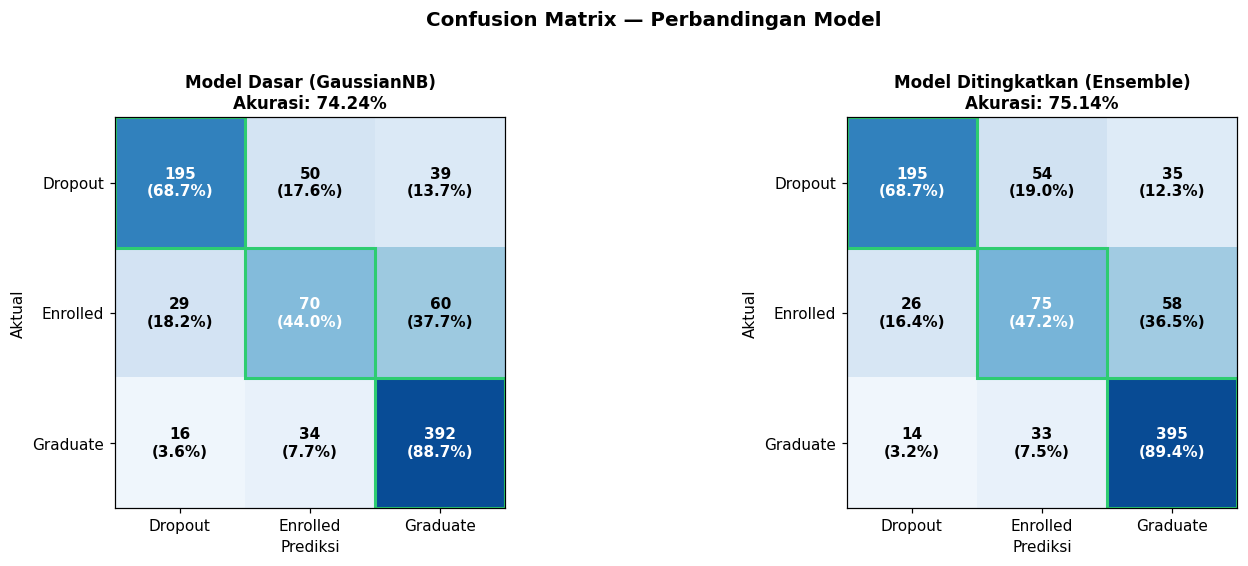

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pasangan = [
    ('Model Dasar (GaussianNB)', prediksi_dasar, akurasi_dasar),
    ('Model Ditingkatkan (Ensemble)', prediksi_ensemble, akurasi_ensemble)
]

for ax, (judul, prediksi, akurasi) in zip(axes, pasangan):
    cm   = confusion_matrix(y_uji, prediksi)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(KELAS, fontsize=10)
    ax.set_yticklabels(KELAS, fontsize=10)
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)
    ax.set_title(f'{judul}\nAkurasi: {akurasi*100:.2f}%', fontweight='bold', fontsize=11)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]*100:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_n[i,j] > 0.4 else 'black',
                    fontweight='bold')
    for k in range(3):
        ax.add_patch(plt.Rectangle((k-0.5, k-0.5), 1, 1, fill=False,
                                     edgecolor='#2ecc71', linewidth=2))

plt.suptitle('Confusion Matrix — Perbandingan Model', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Kurva ROC

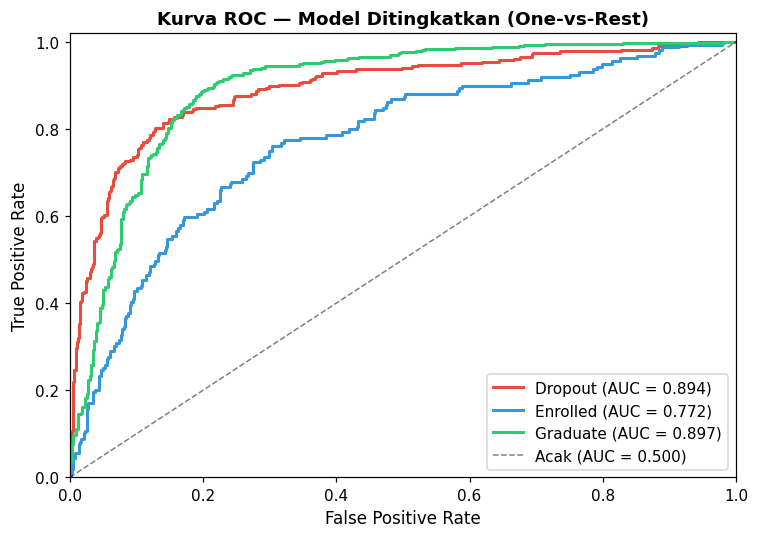

In [16]:
# ROC Curve model terbaik (One-vs-Rest)
y_uji_biner   = label_binarize(y_uji, classes=[0, 1, 2])
prob_ensemble = model_ensemble.predict_proba(X_uji)

fig, ax = plt.subplots(figsize=(7, 5))
warna_roc = ['#e74c3c', '#3498db', '#2ecc71']

for i, (kls, wrn) in enumerate(zip(KELAS, warna_roc)):
    fpr, tpr, _ = roc_curve(y_uji_biner[:, i], prob_ensemble[:, i])
    nilai_auc   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=wrn, linewidth=2, label=f'{kls} (AUC = {nilai_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Acak (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Kurva ROC — Model Ditingkatkan (One-vs-Rest)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### 5.3 Perbandingan Akurasi dan CV

In [17]:
# Tabel ringkasan metrik
f1_dasar    = f1_score(y_uji, prediksi_dasar,    average='macro')
f1_ensemble = f1_score(y_uji, prediksi_ensemble, average='macro')

print('='*65)
print('  RINGKASAN PERBANDINGAN MODEL')
print('='*65)
print(f'{"Metrik":<30} {"Model Dasar":>15} {"Model Ensemble":>15}')
print('-'*65)
print(f'{"Akurasi Data Uji":<30} {akurasi_dasar*100:>14.2f}% {akurasi_ensemble*100:>14.2f}%')
print(f'{"CV 10-Fold (Mean)":<30} {cv_dasar.mean()*100:>14.2f}% {cv_ensemble.mean()*100:>14.2f}%')
print(f'{"CV 10-Fold (Std)":<30} {cv_dasar.std()*100:>14.2f}% {cv_ensemble.std()*100:>14.2f}%')
print(f'{"F1-Score Macro":<30} {f1_dasar*100:>14.2f}% {f1_ensemble*100:>14.2f}%')
print('-'*65)
peningkatan = (akurasi_ensemble - akurasi_dasar) * 100
print(f'Peningkatan akurasi: +{peningkatan:.2f}%')
print('='*65)

  RINGKASAN PERBANDINGAN MODEL
Metrik                             Model Dasar  Model Ensemble
-----------------------------------------------------------------
Akurasi Data Uji                        74.24%          75.14%
CV 10-Fold (Mean)                       74.34%          74.93%
CV 10-Fold (Std)                         1.91%           1.62%
F1-Score Macro                          67.73%          68.94%
-----------------------------------------------------------------
Peningkatan akurasi: +0.90%


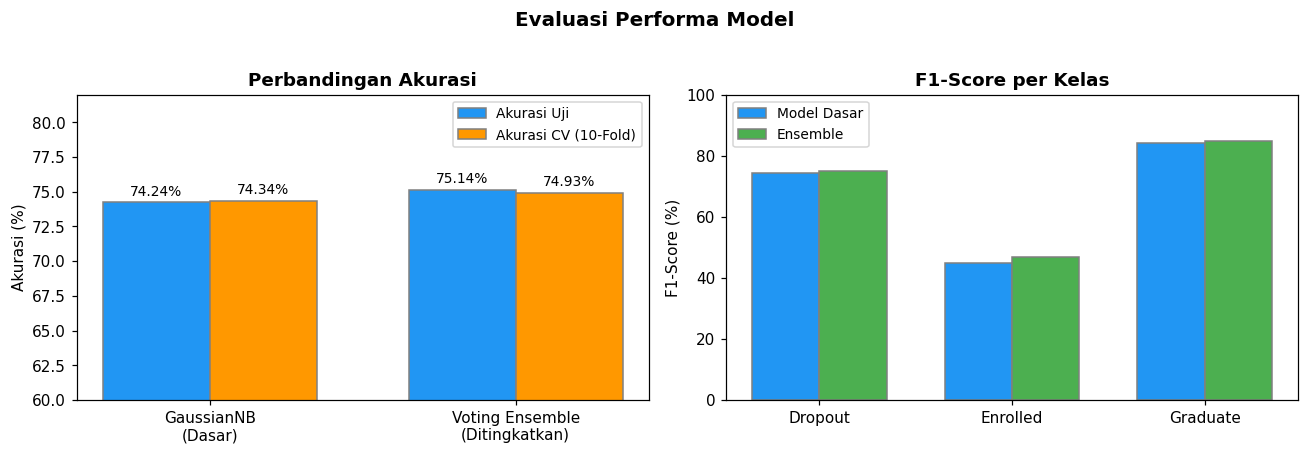

In [18]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart akurasi
model_nama = ['GaussianNB\n(Dasar)', 'Voting Ensemble\n(Ditingkatkan)']
akurasi_test = [akurasi_dasar * 100, akurasi_ensemble * 100]
akurasi_cv   = [cv_dasar.mean() * 100, cv_ensemble.mean() * 100]

x = np.arange(2)
lebar = 0.35
axes[0].bar(x - lebar/2, akurasi_test, lebar, label='Akurasi Uji',
            color='#2196F3', edgecolor='gray')
axes[0].bar(x + lebar/2, akurasi_cv,   lebar, label='Akurasi CV (10-Fold)',
            color='#FF9800', edgecolor='gray')
for i, (t, c) in enumerate(zip(akurasi_test, akurasi_cv)):
    axes[0].text(i - lebar/2, t + 0.3, f'{t:.2f}%', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + lebar/2, c + 0.3, f'{c:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_nama, fontsize=10)
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_title('Perbandingan Akurasi', fontweight='bold')
axes[0].set_ylim(60, 82)
axes[0].legend(fontsize=9)

# Bar chart F1 per kelas
f1_per_kelas_dasar    = [f1_score(y_uji, prediksi_dasar,    average=None)[i] * 100 for i in range(3)]
f1_per_kelas_ensemble = [f1_score(y_uji, prediksi_ensemble, average=None)[i] * 100 for i in range(3)]
x2 = np.arange(3)
axes[1].bar(x2 - lebar/2, f1_per_kelas_dasar,    lebar, label='Model Dasar',
            color='#2196F3', edgecolor='gray')
axes[1].bar(x2 + lebar/2, f1_per_kelas_ensemble, lebar, label='Ensemble',
            color='#4CAF50', edgecolor='gray')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(KELAS, fontsize=10)
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('F1-Score per Kelas', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)

plt.suptitle('Evaluasi Performa Model', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Kesimpulan

Berdasarkan hasil implementasi Naive Bayes pada dataset akademik mahasiswa, diperoleh kesimpulan sebagai berikut:

In [19]:
print('=' * 65)
print('  KESIMPULAN')
print('=' * 65)

print(f'''
1. DATASET
   Dataset terdiri dari {len(df_data):,} data mahasiswa dengan 3 kelas
   target: Graduate ({(df_data['Status']=='Graduate').sum():,}),
   Dropout ({(df_data['Status']=='Dropout').sum():,}), dan
   Enrolled ({(df_data['Status']=='Enrolled').sum():,}).

2. PRA-PEMROSESAN
   Tidak ditemukan duplikat maupun missing value. Outlier ditangani
   menggunakan metode Winsorizing (IQR). Ditambahkan {len(fitur_baru)} fitur
   engineered dan dilakukan seleksi fitur dengan Mutual Information,
   menghasilkan {len(fitur_terpilih)} fitur terpilih.

3. MODEL DASAR (GaussianNB)
   Akurasi data uji  : {akurasi_dasar*100:.2f}%
   Akurasi CV 10-fold: {cv_dasar.mean()*100:.2f}% ± {cv_dasar.std()*100:.2f}%

4. MODEL DITINGKATKAN (Soft Voting Ensemble)
   Strategi peningkatan:
   a) PowerTransformer (Yeo-Johnson) → memperbaiki distribusi skewed
      agar lebih mendekati asumsi Gaussian NB
   b) Pencarian var_smoothing optimal dengan Cross-Validation
   c) Soft Voting Ensemble (GNB+YeoJ, GNB+Scaler, ComplementNB)
      → mengurangi varian prediksi

   Akurasi data uji  : {akurasi_ensemble*100:.2f}%
   Akurasi CV 10-fold: {cv_ensemble.mean()*100:.2f}% ± {cv_ensemble.std()*100:.2f}%
   Peningkatan       : +{peningkatan:.2f}%

5. ANALISIS PER KELAS
   Graduate & Dropout berhasil diprediksi dengan baik (F1 > 70%).
   Kelas Enrolled lebih sulit karena pola fiturnya berada di antara
   kedua kelas lainnya (mahasiswa yang belum selesai studi).

6. AUC (Area Under Curve) — Model Ensemble:
   Dropout  : {auc(*roc_curve(y_uji_biner[:,0], prob_ensemble[:,0])[:2]):.3f}
   Enrolled : {auc(*roc_curve(y_uji_biner[:,1], prob_ensemble[:,1])[:2]):.3f}
   Graduate : {auc(*roc_curve(y_uji_biner[:,2], prob_ensemble[:,2])[:2]):.3f}
   (AUC mendekati 1.0 menunjukkan kemampuan klasifikasi yang baik)
''')
print('=' * 65)

  KESIMPULAN

1. DATASET
   Dataset terdiri dari 4,424 data mahasiswa dengan 3 kelas
   target: Graduate (2,209),
   Dropout (1,421), dan
   Enrolled (794).

2. PRA-PEMROSESAN
   Tidak ditemukan duplikat maupun missing value. Outlier ditangani
   menggunakan metode Winsorizing (IQR). Ditambahkan 8 fitur
   engineered dan dilakukan seleksi fitur dengan Mutual Information,
   menghasilkan 28 fitur terpilih.

3. MODEL DASAR (GaussianNB)
   Akurasi data uji  : 74.24%
   Akurasi CV 10-fold: 74.34% ± 1.91%

4. MODEL DITINGKATKAN (Soft Voting Ensemble)
   Strategi peningkatan:
   a) PowerTransformer (Yeo-Johnson) → memperbaiki distribusi skewed
      agar lebih mendekati asumsi Gaussian NB
   b) Pencarian var_smoothing optimal dengan Cross-Validation
   c) Soft Voting Ensemble (GNB+YeoJ, GNB+Scaler, ComplementNB)
      → mengurangi varian prediksi

   Akurasi data uji  : 75.14%
   Akurasi CV 10-fold: 74.93% ± 1.62%
   Peningkatan       : +0.90%

5. ANALISIS PER KELAS
   Graduate & Dropout ber